## Generation of Dataset for Pole (06)

Run this notebook to generate multiple line shapes using pole configuration #06: 1 pole in $[bb]$ and 1 pole in $[bt]$ sheet

[ 1.97398329 16.31895786 10.31129293  5.33821605 14.6894642  19.85384207
 13.63733444  5.931418   19.80519244 12.52589259  8.38873719  3.31725193
 18.07056836 17.14131902 14.66958616 10.16430767  9.94688876  4.00800591
  9.92067418 13.72034478 16.50066952  3.61958103  5.8021854  17.40325708
 17.64581929 14.67315026 11.11572131  8.9889067  10.80573771  5.16873803
  1.8462941  11.50973941  6.17680854  0.32483377 16.46947392  0.57248093
  6.61394164  2.97652697 13.33492017 18.11313582  6.30182118 10.33175544
 11.2053324   8.87545139 17.05148644 17.01139661  4.05343626 14.91718404
  7.31291336  1.33967743  6.22430574 15.43485751  3.87076022  3.52226833
  4.50128022  6.53937953  6.58704931  6.79799566  4.94308197  6.42149305
 13.10247502  3.75615014  7.50490149  7.43488441  4.3802715  14.85332594
  3.68562956  3.9591833   0.39238422 15.35573808  3.33697658  9.61772626
  3.09870779 14.80044116 18.47284634 13.93728248 16.15427751  1.69200173
 15.32130508 17.79008125 13.61003985  0.45504381 19

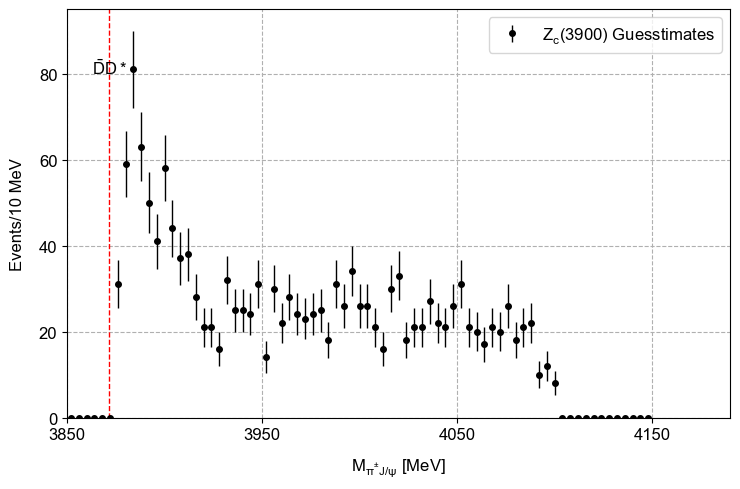

Fit Values:
<ValueView a=7124.652402775101 b=-0.0016056026551119753 c=-6287.958430602658 d=-197.62356358002916>

Fit Errors:
<ErrorView a=26.9193167215858 b=0.0002477632083537386 c=7.320483813417013 d=6.5445426520948615>


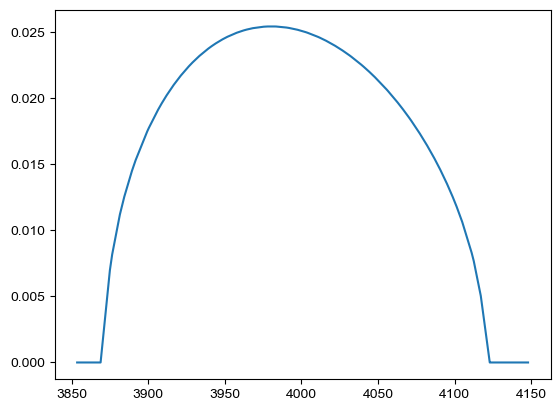

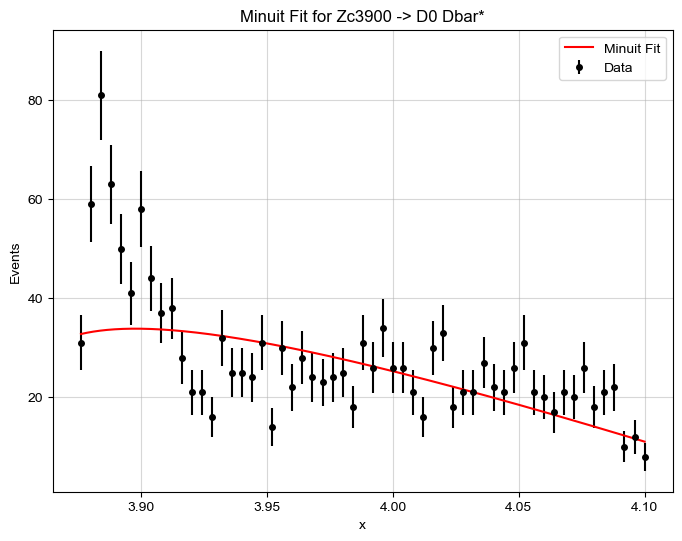

Fit Values:
<ValueView a=7323.403919553659 b=-0.004480443495921923 c=-6239.722337205933 d=-249.9992918195784>

Fit Errors:
<ErrorView a=652.6807215611043 b=0.000515778871521576 c=157.37210762236828 d=22.559688913261482>


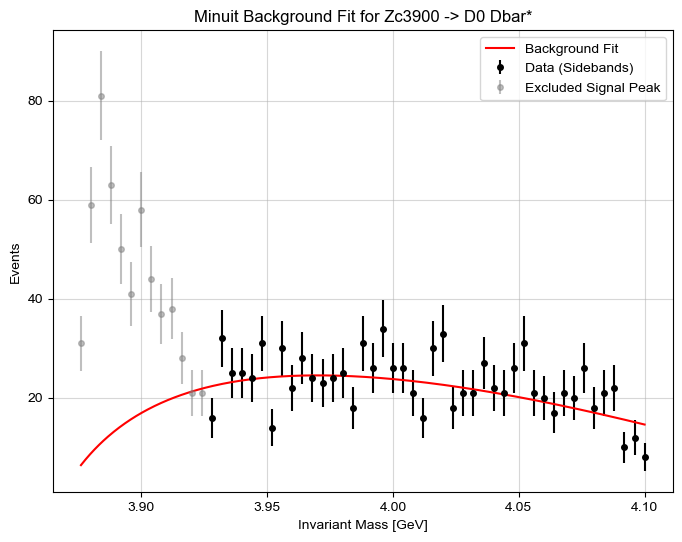

In [1]:
import math
import numpy as np
import cmath as cm
import random
import itertools
import pickle
import os

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from tabulate import tabulate

import sklearn
from sklearn.utils import shuffle

# Import the module containing the class pole
import import_ipynb
import module_Poles
from module_Poles import T1, T2, T4, Nreal, Nimag, TotalN
from module_Poles import unif_pole, gen_Eaxis, skip_duplicate, ddstar_phase_space, bk
from module_Poles import Ereal, Eimag, Erealfar, Eimagfar
from module_Poles import energy_low, energy_high
from module_Poles import invmass, weighted_candidates, upper_err

# Create directory to store data
directory = 'Datasets'
if not os.path.isdir(directory):
    os.makedirs(directory)
out = directory

### Define function

We create a function that can generate 1 pole in $[bb]$-sheet and 1 pole in $[bt]$ sheet and construct its line shape, for `TotalN` times.

In [2]:
# Generate dataset for output label 02: '1 pole in [bb] and [bt]'
def gen_ccdataset04(Ereal, Eimaginput, Erealfar, Eimagfar):

    # Create arrays to store the generated amplitude, energy axis, labels, and parameter info
    energy_axis = []
    ampt22_real = []
    ampt22_imag = []
    amplitude = []
    labelout = []
    data_info = []

    # Possible Riemann sheets
    RSpole = [[-1, 1], [-1, -1], [1, -1]]

    # Shuffle indexing
    for lst in [Ereal, Eimaginput[1], Eimaginput[0], Erealfar, Eimagfar]:
        for _ in range(10):
            np.random.shuffle(lst)
    
    Eimagbb = Eimaginput[1]
    Eimag = Eimaginput[0]
    counter = 1
    # Generate poles in each Riemann sheet
    for real1, imag1 in itertools.product(range(Nreal),range(Nimag)):

        # Randomly choose Riemann sheet
        def rs_choice():
            return np.random.choice([1,2])  # Do not choose relevant Reimann sheet for background
        # To avoid repeated poles, we introduce random index
        indx = skip_duplicate(real1, imag1, Nreal, Nimag)

        # Generate relevant pole in 1[bb] + 1 [bt]-sheet
        pole01 = unif_pole(RSpole[1], Ereal[indx[0][0]], Eimagbb[indx[1][0]] )
        pole02 = unif_pole(RSpole[0], Ereal[indx[0][1]], Eimag[indx[1][1]] )

                # Generate BG poles in different Riemann sheets
        pole1 = unif_pole( RSpole[rs_choice()], Erealfar[indx[0][5]], Eimagfar[indx[1][5]] )
        pole2 = unif_pole( RSpole[rs_choice()], Erealfar[indx[0][6]], Eimagfar[indx[1][6]] )
        pole3 = unif_pole( RSpole[rs_choice()], Erealfar[indx[0][7]], Eimagfar[indx[1][7]] )
        pole4 = unif_pole( RSpole[rs_choice()], Erealfar[indx[0][8]], Eimagfar[indx[1][8]] )
        pole5 = unif_pole( RSpole[rs_choice()], Erealfar[indx[0][9]], Eimagfar[indx[1][9]] )
        pole6 = unif_pole( RSpole[rs_choice()], Erealfar[indx[0][10]], Eimagfar[indx[1][10]] )

        # Generate random energy axis
        Einput = gen_Eaxis()
        Einput = np.array(Einput)

        # Calculate the phase space from the Dalitz plot
        phase_space = ddstar_phase_space(Einput)
        lower_bound = (2006.85 + 1864.84) / 1000  
        upper_bound = 4100 / 1000               
        # 2. Calculate the background values
        bg = bk(Einput/1000, 7323.4039, -0.00448, -6239.722, -249.999)
        
        # 3. Create a boolean mask (True for values INSIDE your desired range)
        mask = (Einput/1000 >= lower_bound) & (Einput/1000 <= upper_bound)

        bg = np.where(mask, bg, 0)
        # Cut both axes to our region of interest
        #phase_space = phase_space[Einput < energy_high]
        #Einput = Einput[Einput < energy_high]
        #phase_space = phase_space[Einput >= energy_low]
        Einput = Einput[Einput >= energy_low]

        
        # S11 for the main poles
        smat11_01 = np.array(pole01.smat11(Einput), dtype=np.complex128)
        smat11_02 = np.array(pole02.smat11(Einput))
        #smat11_03 = np.array(pole03.smat11(Einput))
        #smat11_04 = np.array(pole04.smat11(Einput))
        
        # S11 for the BG poles
        smat11_1 = np.array(pole1.smat11(Einput))#, dtype=np.complex128)
        smat11_2 = np.array(pole2.smat11(Einput))
        smat11_3 = np.array(pole3.smat11(Einput))
        smat11_4 = np.array(pole4.smat11(Einput))
        smat11_5 = np.array(pole5.smat11(Einput))
        smat11_6 = np.array(pole6.smat11(Einput))

        # S22 main
        smat22_01 = np.array(pole01.smat22(Einput))
        smat22_02 = np.array(pole02.smat22(Einput))
        #smat22_03 = np.array(pole03.smat22(Einput))
        #smat22_04 = np.array(pole04.smat22(Einput))

        # S22 BG
        smat22_1 = np.array(pole1.smat22(Einput))
        smat22_2 = np.array(pole2.smat22(Einput))
        smat22_3 = np.array(pole3.smat22(Einput))
        smat22_4 = np.array(pole4.smat22(Einput))
        smat22_5 = np.array(pole5.smat22(Einput))
        smat22_6 = np.array(pole6.smat22(Einput))

        # DetS main
        smatdet_01 = np.array(pole01.smatdet(Einput))
        smatdet_02 = np.array(pole02.smatdet(Einput))
        #smatdet_03 = np.array(pole03.smatdet(Einput))
        #smatdet_04 = np.array(pole04.smatdet(Einput))
        
        # DetS BG
        smatdet_1 = np.array(pole1.smatdet(Einput))
        smatdet_2 = np.array(pole2.smatdet(Einput))
        smatdet_3 = np.array(pole3.smatdet(Einput))
        smatdet_4 = np.array(pole4.smatdet(Einput))
        smatdet_5 = np.array(pole5.smatdet(Einput))
        smatdet_6 = np.array(pole6.smatdet(Einput))
        
        # Random on/off switch for irrelevant poles
        q1 = np.random.choice([0,1])
        q2 = np.random.choice([0,1])
        q3 = np.random.choice([0,1])
        q4 = np.random.choice([0,1])
        q5 = np.random.choice([0,1])
        q6 = np.random.choice([0,1])
        
        # Calculate combined S11
        SMAT = smat11_01 *smat11_02#*smat11_03#*smat11_04
        BGSM = ((1-q1) + q1*smat11_1)*((1-q2)+q2*smat11_2)*((1-q3)+q3*smat11_3)*((1-q4)+q4*smat11_4)*((1-q5)+q5*smat11_5)*((1-q6)+q6*smat11_6)
        SMAT11 = SMAT*BGSM
        # Calculate combined S22
        SMAT = smat22_01*smat22_02#*smat22_03#*smat22_04
        BGSM = ((1-q1)+q1*smat22_1)*((1-q2)+q2*smat22_2)*((1-q3)+q3*smat22_3)*((1-q4)+q4*smat22_4)*((1-q5)+q5*smat22_5)*((1-q6)+q6*smat22_6)
        SMAT22 = SMAT*BGSM 
        # Calculate combined Sdet
        SMAT = smatdet_01*smatdet_02#*smatdet_03#*smatdet_04
        BGSM = ((1-q1)+q1*smatdet_1)*((1-q2)+q2*smatdet_2)*((1-q3)+q3*smatdet_3)*((1-q4)+q4*smatdet_4)*((1-q5)+q5*smatdet_5)*((1-q6)+q6*smatdet_6)
        SMATdet = SMAT*BGSM   

        # Get partial-wave amplitude
        pwat11 = (SMAT11 - 1.0) / (2j)
        pwat11_real = pwat11.real
        pwat11_imag = pwat11.imag
        pwat22 = np.heaviside(Einput-T2*197.3,0)*(SMAT22 - 1.0) / (2j)
        pwat22_real = pwat22.real
        pwat22_imag = pwat22.imag
        SMAT12sqr = (SMAT11*SMAT22 - SMATdet)
        pwa12sqr = -np.heaviside(Einput-T2*197.3,0)*SMAT12sqr/4.0
        
        mod12sqr = np.abs(pwa12sqr)
        arg12sqr = np.unwrap(np.array([np.angle(z) for z in pwa12sqr]))
        pwa12 = np.heaviside(Einput-T2*197.3,0)*np.sqrt(mod12sqr)*np.exp(1j*0.5*arg12sqr)
        
       #Calculate the amplitude
        rate1 = 1.0 #Let the parameter Pr moderate the transition
        rate2 = np.random.normal(1.00, 0.40)
        pwatadd = rate1*pwat22 + rate2*pwa12
        PWAT = (pwatadd.real)**2.0 + (pwatadd.imag)**2.0
        # Combine with a polynomial bg and get the total lineshape
        #poly_bg = polynom(Einput)
        A = np.random.uniform(30, 45)
        N = np.random.normal(10,1 )
        totamp =A*(phase_space*PWAT*N) + bg#*dGamma with |M|=1
        #totamp = np.rot90(totamp, k=3)
        #totamp[np.where(phase_space==0)] = -1
        #totamp += 1
        #totamp = np.sum(totamp, axis=1)
        # Collect data
        energy_axis.append(Einput)
        ampt22_real.append(pwat22_real)
        ampt22_imag.append(pwat22_imag)
        amplitude.append(totamp)
       
        
        # Create label (as output in DNN)
        labelout.append(1)

        # Collect parameters
        information = [[pole01.pos, pole02.pos, pole1.pos, pole2.pos, pole3.pos, pole4.pos, pole5.pos, pole6.pos],
                       [pole01.RS, pole02.RS, pole1.RS, pole2.RS, pole3.RS, pole4.RS, pole5.RS, pole6.RS],
                       [1, 1, q1, q2, q3, q4, q5, q6]]

        data_info.append(information)

        # Print a counter to keep track of progress
        if counter < 10 or counter % 100 == 0:
            print('Generated ' +str(counter)+' of '+str(TotalN))
        counter = counter +1

    return energy_axis, ampt22_real, ampt22_imag, amplitude, labelout, data_info

### Generate Dataset

Let us now allow the computer to generate the dataset. This is where we have to wait.

In [3]:
# Call the function above
data_energy, data_t11real, data_t11imag, data_amps, outputs, data_info = gen_ccdataset04(Ereal, Eimag, Erealfar, Eimagfar)

print("Done generating!")

Generated 1 of 10000
Generated 2 of 10000
Generated 3 of 10000
Generated 4 of 10000
Generated 5 of 10000
Generated 6 of 10000
Generated 7 of 10000
Generated 8 of 10000
Generated 9 of 10000
Generated 100 of 10000
Generated 200 of 10000
Generated 300 of 10000
Generated 400 of 10000
Generated 500 of 10000
Generated 600 of 10000
Generated 700 of 10000
Generated 800 of 10000
Generated 900 of 10000
Generated 1000 of 10000
Generated 1100 of 10000
Generated 1200 of 10000
Generated 1300 of 10000
Generated 1400 of 10000
Generated 1500 of 10000
Generated 1600 of 10000
Generated 1700 of 10000
Generated 1800 of 10000
Generated 1900 of 10000
Generated 2000 of 10000
Generated 2100 of 10000
Generated 2200 of 10000
Generated 2300 of 10000
Generated 2400 of 10000
Generated 2500 of 10000
Generated 2600 of 10000
Generated 2700 of 10000
Generated 2800 of 10000
Generated 2900 of 10000
Generated 3000 of 10000
Generated 3100 of 10000
Generated 3200 of 10000
Generated 3300 of 10000
Generated 3400 of 10000
Gene

### Inspect and Export

Plot the generated line shapes and inspect validity of dataset.

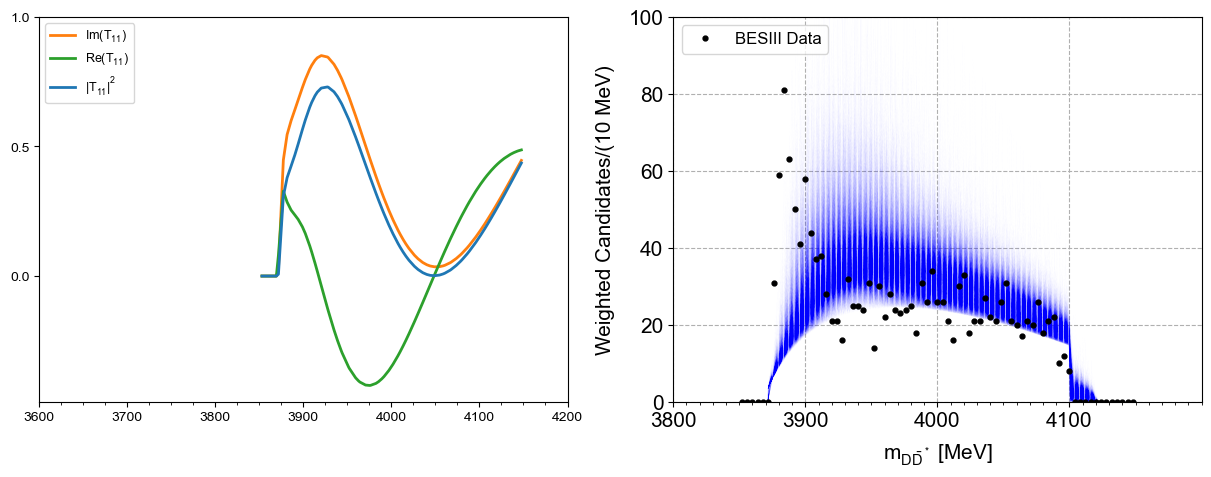

Data #3445 parameters:
#     Energy pole (MeV)                         RS          Active?
----  ----------------------------------------  --------  ---------
[bb]  (3865.4533940737597-16.93703565659539j)   [-1, -1]          1
[bt]  (3879.7745200614067-14.689464199632695j)  [-1, 1]           1
1     (2279.085865286507-1114.1388541417155j)   [1, -1]           0
2     (2362.5639103179615-1924.3591790051194j)  [-1, -1]          0
3     (2267.5467078110632-529.128512219206j)    [-1, -1]          0
4     (2585.202536379056-1401.9007276428665j)   [1, -1]           1
5     (3160.0472559364266-572.7174081705106j)   [-1, -1]          1
6     (2930.7949458427574-706.1750297122672j)   [-1, -1]          1
[3853.09600438 3858.36716571 3862.42412356 3864.91438106 3869.42412976
 3871.75748435 3877.3341446  3881.6069668  3886.14771594 3890.39447931
 3894.12813375 3898.979546   3902.28477126 3907.32095603 3909.5131182
 3913.26187779 3915.90315215 3920.39253461 3927.39831926 3928.42194292
 3934.84595956

In [4]:
# Randomly select one amplitude from the generated dataset
indx = random.sample(range(len(data_amps)), 1)[0]

# Plot PWAT_11
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(data_energy[indx], data_t11imag[indx], label = "$Im(T_{22})$", color="tab:orange", linewidth = 2)
ax1.plot(data_energy[indx], data_t11real[indx], label = "$Re(T_{22})$", color="tab:green", linewidth = 2)
ax1.plot(data_energy[indx], data_t11real[indx]**2 + data_t11imag[indx]**2, label = "$|T_{22}|^2$", color="tab:blue",linewidth = 2)
ax1.legend(loc = 'upper left', fontsize = 9)
ax1.set_xticks(np.arange(3600,4200, 100))
ax1.set_yticks([0.0, 0.5, 1.0])
ax1.xaxis.set_major_locator(MultipleLocator(100))
ax1.xaxis.set_minor_locator(MultipleLocator(25))
ax1.set_xlim([3600,4200])
ax1.margins(x=0)

# Plot total line shape
ax2.plot(data_energy, data_amps, linewidth = 0.001, color = 'blue')
ax2.errorbar(invmass, (weighted_candidates), fmt = 'o',
            ecolor = "k", color = "k", elinewidth = 1, markersize = 3.5, label = "BESIII Data")
ax2.set_xticks(np.arange(3600,4200,100))
#ax2.set_yticks(np.arange(0,100,25))
ax2.xaxis.set_minor_locator(MultipleLocator(10))
ax2.tick_params(axis='both', which='major', labelsize=15)
ax2.set_xlabel(r'$m_{D \bar{D}^*}$ [MeV]', fontsize = 15, labelpad=8)
ax2.set_ylabel('Weighted Candidates/(10 MeV)', fontsize = 15, labelpad=10)
ax2.margins(x=0)
ax2.grid(True, linestyle='--')
ax2.legend(loc = 'upper left', fontsize = 12)
ax2.set_xlim([3800,4200])
ax2.set_ylim([0, 100])

plt.show()

# Print the parameters used for the particular line shape
pars1 = data_info[indx]
addn = 1
table1 = [["#","Energy pole (MeV)","RS","Active?"], 
          ["[bb]", str(pars1[0][0]), pars1[1][0], pars1[2][0]],
          ["[bt]", str(pars1[0][1]), pars1[1][1], pars1[2][1]],
          ["1", str(pars1[0][1+addn]), pars1[1][1+addn], pars1[2][1+addn]],
          ["2", str(pars1[0][2+addn]), pars1[1][2+addn], pars1[2][2+addn]],
          ["3", str(pars1[0][3+addn]), pars1[1][3+addn], pars1[2][3+addn]],
          ["4", str(pars1[0][4+addn]), pars1[1][4+addn], pars1[2][4+addn]],
          ["5", str(pars1[0][5+addn]), pars1[1][5+addn], pars1[2][5+addn]],
          ["6", str(pars1[0][6+addn]), pars1[1][6+addn], pars1[2][6+addn]]]


print("Data #"+str(indx)+" parameters:")
print(tabulate(table1, headers="firstrow"))

print(data_energy[indx])

In [6]:
# Convert arrays
data_amps = np.array(data_amps)
data_energy = np.array(data_energy)

# Concatenate energy axis and intensity axis (as input in DNN)
inputs = np.concatenate((data_energy,data_amps),axis=1)

# Export dataset to directory
#Be mindful of the filename
pickle.dump(data_amps, open(os.path.join(out,'P01_intensity.pkl'),'wb'), protocol=4)
pickle.dump(data_energy, open(os.path.join(out,'P01_energy.pkl'),'wb'), protocol=4)
pickle.dump(inputs, open(os.path.join(out,'P01inputs_valid.pkl'),'wb'), protocol=4)
pickle.dump(outputs, open(os.path.join(out,'P01outputs_test.pkl'),'wb'), protocol=4)
pickle.dump(data_info, open(os.path.join(out, 'P01data_info.pkl'),'wb'), protocol=4)

print('Done exporting!')

Done exporting!
